# Econ 107 Final Project — Streamlined Pipeline

This notebook is a refactored version of the original analysis. All repetitive logic
(name normalization, KMeans-with-elbow plots, PCA visualization, the model horse race)
has been pulled into reusable functions defined in the **Setup section**.

**To re-run the full analysis:**
1. Run the Setup cells (Section 0) once — they define all functions and constants.
2. Then run the pipeline cells in order (Sections 1–8).

> **Note on Section 8.** Sections 1–7 derive green/sin exposure from *fund-name keyword
> matching*. Section 8 supersedes that tilt analysis with a **richer 2024 dataset** that
> attaches S&P Global ESG scores and CSA industry classifications at the holding level.
> Green is now a curated company list, sin and neutral are CSA-industry regexes, and the
> tests add Hedges' *g*, confidence intervals, Welch *t*, and Mann–Whitney *U*, plus a
> score-tier tilt alongside the involvement tilt. The ESG fund labels (`is_esg_final`)
> still come from Section 2.

**Reproducibility.** Paths are configured once in Section 0.2 (`DATA_DIR` / `OUTPUT_DIR`,
both overridable by environment variables). Place the input files in `./data` and the
notebook writes every table and figure to `./outputs`. See `README.md` for setup and
`data/README.md` for data provenance, access, and file schemas.

**Pipeline outline:**
- Section 1: Load and normalize holdings data
- Section 2: Classify funds as ESG (keyword + semantic embeddings + whitelist/blacklist)
- Section 3: Sample composition analysis
- Section 4: Cluster ESG and non-ESG funds
- Section 5: Build fund-level features for ML
- Section 6: Horse race — predicting ESG label from holdings
- Section 7: Baseline AUCs — is ESG distinctively hard to predict from holdings?
- Section 8: Benchmark-adjusted tilt & green/sin/neutral analysis (richer ESG-scored dataset)


## Section 0 — Setup

All imports, constants, and helper functions live here.

In [32]:
# ── 0.1  Install dependencies (run once) ─────────────────────────────────
# Uncomment the line below the first time you run this notebook.
%pip install requests pandas tqdm lxml sentence-transformers scikit-learn xgboost matplotlib seaborn scipy


Note: you may need to restart the kernel to use updated packages.


In [33]:
# ── 0.2  Imports & global config ─────────────────────────────────────────
import os
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.preprocessing      import StandardScaler
from sklearn.decomposition      import PCA
from sklearn.cluster            import KMeans, MiniBatchKMeans
from sklearn.metrics            import silhouette_score, roc_auc_score, roc_curve
from sklearn.metrics.pairwise   import cosine_similarity
from sklearn.model_selection    import train_test_split, ParameterGrid
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import (RandomForestClassifier,
                                        GradientBoostingClassifier,
                                        BaggingClassifier)
from sklearn.dummy              import DummyClassifier

warnings.filterwarnings("ignore")

# ── File-path configuration (portable / reproducible) ────────────────────
# INPUTS live in DATA_DIR; everything this notebook GENERATES lands in OUTPUT_DIR.
# Override either via an environment variable; otherwise they default to the
# repo-relative ./data and ./outputs folders so a fresh clone runs as-is.
#   export ESG_DATA_DIR=/path/to/your/data        # optional
#   export ESG_OUTPUT_DIR=/path/to/your/outputs   # optional
DATA_DIR   = Path(os.environ.get("ESG_DATA_DIR",   "data"))
OUTPUT_DIR = Path(os.environ.get("ESG_OUTPUT_DIR", "outputs"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE         = str(DATA_DIR / "nport_holdings_2024.csv")   # public SEC N-PORT scrape
ESG_HOLDINGS_FILE = str(OUTPUT_DIR / "esg_holdings.csv")        # generated
RANDOM_STATE      = 42


In [34]:
# ── 0.3  Data loading & name normalization ───────────────────────────────
def normalize_security_name(name):
    """Standardize security names (uppercase, strip punctuation, unify suffixes)."""
    if pd.isna(name):
        return ""
    name = str(name).upper()
    name = re.sub(r"[.,/\\]", "", name)
    name = re.sub(r"\s+", " ", name).strip()
    name = re.sub(r"\bCORPORATION\b", "CORP", name)
    name = re.sub(r"\bINCORPORATED\b", "INC",  name)
    name = re.sub(r"\bLIMITED\b",     "LTD",  name)
    name = re.sub(r"\bCOMPANY\b",     "CO",   name)
    name = re.sub(r"\bAND\b",         "&",    name)
    return name


def load_holdings(path=DATA_FILE, normalize_names=True):
    """Load N-PORT holdings CSV, coerce numeric cols, optionally normalize names."""
    df = pd.read_csv(path)
    df["pct_nav"]   = pd.to_numeric(df["pct_nav"],   errors="coerce").fillna(0)
    df["value_usd"] = pd.to_numeric(df["value_usd"], errors="coerce").fillna(0)
    if normalize_names:
        df["security_name_clean"] = df["security_name"].apply(normalize_security_name)
    return df


In [57]:
# ── 0.4  ESG classification helpers (refined / stricter version) ─────────
#
# Changes vs. original:
#   * threshold_net raised 0.1 → 0.2
#   * NEW min_pos_sim: absolute floor on similarity to the best ESG anchor
#   * NEW multi-anchor agreement: must be close to >= min_strong_anchors
#     positive anchors
#   * Negative baseline uses mean of top-k negative similarities instead of
#     a single max (harder to "dodge" the negative side)
#   * Whitelist / blacklist patterns and override logic are UNCHANGED:
#     whitelist hits are always ESG; blacklist (non-whitelisted) always not.

import re
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Keyword whitelist / blacklist used to override semantic classifier
ESG_WHITELIST_PATTERNS = [
    r"\besg\b", r"\bsustain\w*\b", r"\bresponsible invest\w*\b",
    r"\bsocially responsible\b", r"\bsri\b", r"\bethical\b",
    r"\bimpact invest\w*\b", r"\bimpact\b", r"\bconscious\b",
    r"\bvalues.based\b", r"\bvalue.based\b",
    r"\bclimate\b", r"\bgreen\b", r"\bcarbon\b", r"\bclean energy\b",
    r"\brenewable\b", r"\benvironmental\b", r"\benviron\w*\b",
    r"\bnet.zero\b", r"\blow.carbon\b", r"\bfossil.free\b", r"\bcleantech\b",
    r"\bdiversity\b", r"\binclusion\b", r"\bgender\b", r"\bwomen\b",
    r"\bhuman rights\b", r"\bcommunity development\b", r"\bmicrofinance\b",
    r"\bcatholic\b", r"\bchristian\b", r"\bfaith.based\b", r"\bfaith based\b",
    r"\bbiblical\b", r"\bmorally\b",
    r"\bstewardship\b", r"\bcorporate governance\b",
]

NON_ESG_PATTERNS = [
    r"\bvalue equity\b", r"\bvalue fund\b", r"\bvalue portfolio\b",
    r"\bvalue strategies\b", r"\bvalue stock\b", r"\brelative value\b",
    r"\bcore value\b", r"\bgrowth.{0,5}value\b",
    r"\binternational equity\b", r"\bglobal equity\b",
    r"\bemerging markets equity\b", r"\bsmall.?cap equity\b",
    r"\bmid.?cap equity\b", r"\blarge.?cap equity\b",
    r"\bmulti.?factor\b", r"\blow volatility\b",
    r"\bcore equity\b", r"\bgrowth equity\b", r"\bblend\b",
    r"\btechnology\b", r"\bhealthcare\b", r"\bfinancial services\b",
    r"\benergy\b(?! transition| clean| renew)", r"\butilities\b",
    r"\bindustrials\b", r"\bconsumer staples\b",
    r"\bconsumer discretionary\b", r"\bmaterials\b",
    r"\bmoney market\b", r"\btreasury\b", r"\bgovernment bond\b",
    r"\bhigh yield\b", r"\binflation\b", r"\bfloating rate\b",
    r"\bshort.?term\b", r"\bultra.?short\b",
    r"\btarget date\b", r"\bretirement \d{4}\b", r"\bdividend\b",
    r"\bincome equity\b", r"\barbitrage\b", r"\blong.?short\b",
    r"\bmarket neutral\b", r"\bhedge\b", r"\bleveraged\b",
    r"\binverse\b", r"\bquantitative\b", r"\bsystematic\b",
]


def _matches_any(text, patterns):
    text_lower = str(text).lower()
    return any(re.search(p, text_lower) for p in patterns)


def is_whitelisted(name):
    return _matches_any(name, ESG_WHITELIST_PATTERNS)


def is_blacklisted(name):
    """Blacklisted only if non-ESG patterns match AND not whitelisted."""
    if is_whitelisted(name):
        return False
    return _matches_any(name, NON_ESG_PATTERNS)


# ── Anchors used by the sentence-embedding step ──────────────────────────
ESG_ANCHORS = [
    "ESG fund incorporating environmental social and governance factors",
    "sustainable responsible investing fund",
    "socially responsible investment fund",
    "fund that screens investments based on ethical criteria",
    "values based investment fund",
    "impact investing fund for positive social and environmental outcomes",
    "fund investing in climate change solutions",
    "clean energy and renewable energy investment fund",
    "low carbon and carbon neutral investment portfolio",
    "green fund avoiding fossil fuels",
    "environmental sustainability fund",
    "fund focused on climate transition and net zero emissions",
    "fund promoting social equity diversity and inclusion",
    "community development and affordable housing fund",
    "fund supporting human rights and fair labor practices",
    "gender diversity and women empowerment investment fund",
    "fund focused on corporate governance and stewardship",
    "ethical fund with strong accountability and transparency standards",
    "fund selecting companies with responsible business practices",
    "faith based investment fund with moral screening",
    "religiously screened investment fund",
]

NON_ESG_ANCHORS = [
    "general equity fund investing in large cap stocks",
    "index fund tracking market benchmark",
    "value investing fund seeking undervalued stocks",
    "growth fund investing in high growth companies",
    "dividend income fund for yield seeking investors",
    "balanced fund with mix of stocks and bonds",
    "money market fund investing in short term instruments",
    "government bond fund investing in treasury securities",
    "real estate investment trust fund",
    "commodity fund investing in natural resources",
    "technology sector fund",
    "healthcare sector fund",
    "financial services sector fund",
    "small cap equity fund",
    "international equity fund",
    "emerging markets fund",
    "target date retirement fund",
    "multi asset allocation fund",
]


def classify_funds_esg(fund_names,
                       threshold_net=0.45,        # was 0.1 — stricter net margin
                       min_pos_sim=0.5,         # NEW: absolute floor on best ESG-anchor similarity
                       min_strong_anchors=3,     # NEW: must be close to >= 2 ESG anchors
                       strong_anchor_sim=0.48,   # NEW: what counts as "close" for the rule above
                       neg_top_k=3,              # NEW: mean of top-k negative sims (robust baseline)
                       model_name="all-mpnet-base-v2",
                       verbose=True):
    """
    Classify each fund name as ESG or not (stricter semantic rule).

    Decision rule (three tiers, whitelist/blacklist behavior unchanged):
        1. Whitelist regex match            -> ESG, unconditionally
        2. Blacklist match (not whitelisted) -> not ESG, unconditionally
        3. Otherwise, ESG only if ALL of:
              net_esg_score   >= threshold_net
              esg_similarity  >= min_pos_sim
              n_strong_pos    >= min_strong_anchors
           where net_esg_score = max_pos_similarity − mean(top-k neg similarities).

    Returns a DataFrame with columns:
        series_name, esg_similarity, non_esg_sim, net_esg_score,
        n_strong_pos, best_anchor, best_neg_anchor,
        is_whitelisted, is_blacklisted, is_esg_final
    """
    from sentence_transformers import SentenceTransformer

    fund_names = pd.Series(fund_names).dropna().drop_duplicates().reset_index(drop=True)

    if verbose:
        print(f"Loading embedding model {model_name!r}...")
    model = SentenceTransformer(model_name)

    if verbose:
        print(f"Encoding {len(fund_names):,} fund names + anchors...")
    fund_emb = model.encode(fund_names.tolist(), batch_size=256,
                            show_progress_bar=verbose)
    pos_emb  = model.encode(ESG_ANCHORS,     show_progress_bar=False)
    neg_emb  = model.encode(NON_ESG_ANCHORS, show_progress_bar=False)

    pos_sim = cosine_similarity(fund_emb, pos_emb)
    neg_sim = cosine_similarity(fund_emb, neg_emb)

    max_pos = pos_sim.max(axis=1)
    # Robust negative baseline: mean of the top-k negative similarities,
    # so one accidentally-dissimilar negative anchor can't inflate the net score.
    k = min(neg_top_k, neg_sim.shape[1])
    top_k_neg = np.sort(neg_sim, axis=1)[:, -k:].mean(axis=1)

    out = pd.DataFrame({
        "series_name"    : fund_names,
        "esg_similarity" : max_pos,
        "non_esg_sim"    : top_k_neg,
        "net_esg_score"  : max_pos - top_k_neg,
        "n_strong_pos"   : (pos_sim >= strong_anchor_sim).sum(axis=1),
        "best_anchor"    : [ESG_ANCHORS[i]     for i in pos_sim.argmax(axis=1)],
        "best_neg_anchor": [NON_ESG_ANCHORS[i] for i in neg_sim.argmax(axis=1)],
    })

    out["is_whitelisted"] = out["series_name"].apply(is_whitelisted)
    out["is_blacklisted"] = out["series_name"].apply(is_blacklisted)

    out["is_esg_final"] = (
        (
            (out["net_esg_score"]  >= threshold_net)
            & (out["esg_similarity"] >= min_pos_sim)
            & (out["n_strong_pos"]   >= min_strong_anchors)
            & ~out["is_blacklisted"]
        )
        | out["is_whitelisted"]   # whitelist always wins -> always included
    )

    return out.sort_values("net_esg_score", ascending=False).reset_index(drop=True)

In [5]:
# ── 0.5  Clustering helpers ──────────────────────────────────────────────

def build_pivot(df, row="series_name", col="asset_category",
                value="pct_nav", prefix=""):
    """Build a pivot of {row} x {col} aggregating sum of {value}."""
    p = (df.groupby([row, col])[value]
           .sum()
           .unstack(fill_value=0))
    if prefix:
        p.columns = [f"{prefix}{c}" for c in p.columns]
    return p


def select_k(X, k_range=range(2, 12), use_minibatch=False,
             title_prefix="", save_path=None, plot=True,
             silhouette_sample=None):
    """
    Run KMeans for each k, plot inertia (elbow) and silhouette score.
    Returns dict {k: (inertia, silhouette)} so you can pick OPTIMAL_K.
    """
    KM = MiniBatchKMeans if use_minibatch else KMeans
    inertias, sils = [], []
    for k in k_range:
        kw = dict(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        if use_minibatch:
            kw["batch_size"] = 512
        km = KM(**kw)
        labels = km.fit_predict(X)
        sil_kw = {"sample_size": silhouette_sample, "random_state": RANDOM_STATE} \
                 if silhouette_sample else {}
        sil = silhouette_score(X, labels, **sil_kw)
        inertias.append(km.inertia_)
        sils.append(sil)
        print(f"  k={k}  inertia={km.inertia_:.1f}  silhouette={sil:.3f}")

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(list(k_range), inertias, "bo-")
        ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")
        ax1.set_title(f"{title_prefix}Elbow Method".strip())
        ax2.plot(list(k_range), sils, "ro-")
        ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette Score")
        ax2.set_title(f"{title_prefix}Silhouette Score".strip())
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()

    return dict(zip(list(k_range), zip(inertias, sils)))


def fit_kmeans(X, k, use_minibatch=False):
    """Fit a final KMeans (or MiniBatch) and return (model, labels)."""
    KM = MiniBatchKMeans if use_minibatch else KMeans
    kw = dict(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    if use_minibatch:
        kw["batch_size"] = 512
    km = KM(**kw)
    labels = km.fit_predict(X)
    return km, labels


def plot_clusters_pca(X, labels, title="Cluster PCA Projection",
                      save_path=None, clip_percentiles=None,
                      figsize=(10, 7), point_size=80):
    """2-D PCA visualization of clusters, optionally clipping axes to percentiles."""
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X2 = pca.fit_transform(X)
    exp = pca.explained_variance_ratio_ * 100
    n_clusters = len(np.unique(labels))
    colors = [plt.cm.tab10(i) for i in range(n_clusters)]

    plt.figure(figsize=figsize)
    for c in range(n_clusters):
        m = labels == c
        plt.scatter(X2[m, 0], X2[m, 1], color=colors[c],
                    label=f"Cluster {c} (n={m.sum()})",
                    alpha=0.7, s=point_size, edgecolors="white", linewidths=0.5)
    if clip_percentiles is not None:
        lo, hi = clip_percentiles
        x_lo, x_hi = np.percentile(X2[:, 0], [lo, hi])
        y_lo, y_hi = np.percentile(X2[:, 1], [lo, hi])
        plt.xlim(x_lo - 2, x_hi + 2)
        plt.ylim(y_lo - 2, y_hi + 2)
    plt.xlabel(f"PC1 ({exp[0]:.1f}% variance)")
    plt.ylabel(f"PC2 ({exp[1]:.1f}% variance)")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return X2


def describe_clusters(feature_df, label_col="cluster", feature_cols=None,
                      top_n_features=5, n_sample_funds=8):
    """Print top features and sample funds for each cluster."""
    if feature_cols is None:
        feature_cols = [c for c in feature_df.columns if c != label_col]
    profiles = feature_df.groupby(label_col)[feature_cols].mean().round(3)

    print("=== Cluster sizes ===")
    print(feature_df[label_col].value_counts().sort_index())

    print("\n=== Top defining features per cluster ===")
    for c in sorted(feature_df[label_col].unique()):
        top = profiles.loc[c].sort_values(ascending=False).head(top_n_features)
        print(f"\n  Cluster {c}:")
        for f, v in top.items():
            if v > 0:
                print(f"    {f:<40} {v:.3f}")

    print("\n=== Sample funds per cluster ===")
    for c in sorted(feature_df[label_col].unique()):
        funds = feature_df[feature_df[label_col] == c].index.tolist()
        print(f"\n  Cluster {c} ({len(funds)} funds):")
        for f in funds[:n_sample_funds]:
            print(f"    {f}")


In [6]:
# ── 0.6  Industry keywords + fund-level feature engineering ──────────────

INDUSTRY_KEYWORDS = {
    # ── ESG-NEGATIVE industries ───────────────────────────────────────────
    "fossil_fuel": [
        "exxon","xom","chevron","cvx","bp ","b.p.","british petroleum",
        "shell","totalenergies","total se","equinor","eni ",
        "conocophillips","cop ","pioneer natural","pxd",
        "eog resources","devon energy","dvn","coterra","ctra",
        "diamondback","fang","hess corp","marathon oil","mro ",
        "occidental","oxy ","ovintiv","arc resources",
        "energy transfer","kinder morgan","kmі","oneok","ok ",
        "williams cos","targa resources","enterprise products",
        "plains all american","holly frontier",
        "valero","vlo","phillips 66","psx","marathon petroleum",
        "mpc ","pbf energy","par pacific",
        "schlumberger","slb ","halliburton","hal ",
        "baker hughes","bhi ","weatherford","transocean",
        "patterson-uti","helmerich",
        "coal","consol energy","arch resources","alpha metallurgical",
        "foresight energy","peabody","ramaco",
        "petroleum","refining","oil sands","oil & gas",
        "upstream energy","lng ","liquefied natural gas",
    ],
    "tobacco": [
        "philip morris","pm usa","altria","mo ",
        "reynolds american","rai ","british american tobacco","bat ",
        "imperial brands","imb ","japan tobacco","jti ",
        "vector group","liggett","standard commercial",
        "universal corp","star scientific",
    ],
    "weapons_defense": [
        "lockheed martin","lmt ","raytheon","rtx ",
        "northrop grumman","noc ","general dynamics","gd ",
        "l3harris","lhx ","bae systems","huntington ingalls",
        "hii ","textron","txt ","leidos","ldos",
        "booz allen","bah ","saic ","curtiss-wright",
        "heico","transdigm","moog ","kratos",
        "axon enterprise","osi systems",
    ],
    "gambling": [
        "las vegas sands","lvs ","mgm resorts","mgm ",
        "wynn resorts","wynn","caesars","czr ",
        "penn entertainment","penn national","penn gaming",
        "flutter","draftkings","dkng","betmgm",
        "golden nugget","boyd gaming","red rock resorts",
        "scientific games","everi holdings","igt ",
        "international game technology",
    ],
    "alcohol": [
        "anheuser-busch","ab inbev","bud ","diageo","deo ",
        "constellation brands","stz ","molson coors","tap ",
        "brown-forman","bf.b","heineken","pernod ricard",
        "ambev","abev","carlsberg","asahi",
        "boston beer","sam adams","craft brew alliance",
    ],
    "adult_entertainment": [
        "playboy","playtika","acacia research",
        "limelight networks","aylo",
    ],
    # ── ESG-POSITIVE industries ───────────────────────────────────────────
    "renewable_energy": [
        "nextera energy","nee ","enphase","enph",
        "first solar","fslr","sunrun","run ",
        "vestas","orsted","brookfield renewable","bepc",
        "plug power","plug","bloom energy","be ",
        "solaredge","sedg","array technologies","arry",
        "sunpower","spwr","sunnova","nova ",
        "canadian solar","csiq","jinko solar","jks ",
        "daqo new energy","xcel energy","avangrid",
        "clearway energy","pattern energy","terraform",
        "innergex","boralex","northland power",
        "atlantica sustainable","neoen","voltalia",
    ],
    "clean_tech": [
        "tesla","tsla","rivian","rivn","lucid ","lcid",
        "nio ","xpev","li auto","byd ",
        "albemarle","alb ","livent","lthm",
        "chargepoint","chpt","blink charging","blnk",
        "evgo","wallbox","volta industries",
        "ballard power","bldp","fuelcell energy","fcel",
        "itm power","ceres power","powercolor",
        "enovis","itron","ameresco","amrc",
        "clean harbors","us ecology","stericycle",
    ],
    "water": [
        "xylem","xyl ","veolia","american water works","awk ",
        "essential utilities","wtrg","middlesex water","msex",
        "california water","cwt ","york water","yorw",
        "pennichuck","artesian water","artesian resources",
        "mueller water","mwa ","watts water","wtс ",
        "phibro animal","tetra tech","ttek",
        "aecom","jacobs engineering","black & veatch",
    ],
    "healthcare_positive": [
        "unitedhealth","unh ","johnson & johnson","jnj ",
        "abbott laboratories","abt ","medtronic","mdt ",
        "becton dickinson","bdx ","baxter","bax ",
        "zimmer biomet","zbh ","stryker","syk ",
        "boston scientific","bsx ","edwards lifesciences",
        "intuitive surgical","isrg","danaher","dhr ",
        "thermo fisher","tmo ","agilent","a ",
        "waters corp","wat ","mettler-toledo",
    ],
    # ── NEUTRAL / MIXED industries ────────────────────────────────────────
    "big_tech": [
        "microsoft","msft","apple inc","aapl",
        "nvidia","nvda","alphabet","googl","goog ",
        "amazon","amzn","meta platforms","meta ",
        "broadcom","avgo","oracle","orcl",
        "salesforce","crm ","adobe","adbe",
        "servicenow","now ","snowflake","snow ",
        "crowdstrike","crwd","datadog","ddog",
        "workday","wday","fortinet","ftnt",
        "palo alto","panw","zscaler","zs ",
    ],
    "financials": [
        "jpmorgan","jpm ","bank of america","bac ",
        "wells fargo","wfc ","goldman sachs","gs ",
        "morgan stanley","ms ","citigroup","citi",
        "charles schwab","schw","blackrock","blk ",
        "visa","v ","mastercard","ma ",
        "american express","axp ","capital one","cof ",
        "u.s. bancorp","usb ","pnc financial","pnc ",
        "truist","tfc ","regions financial","rf ",
        "fifth third","fitb","huntington bancshares",
    ],
    "real_estate": [
        "prologis","pld ","american tower","amt ",
        "crown castle","cci ","equinix","eqix",
        "simon property","spg ","welltower","well ",
        "digital realty","dlr ","public storage","psa ",
        "extra space","exr ","avalonbay","avb ",
        "equity residential","eqr ","camden property",
        "mid-america","maa ","essex property","ess ",
        "realty income","o ","agree realty","adc ",
    ],
    "pharma": [
        "pfizer","pfe ","merck","mrk ","abbvie","abbv",
        "bristol myers","bmy ","eli lilly","lly ",
        "amgen","amgn","gilead","gild","regeneron","regn",
        "biogen","biib","vertex","vrtx","moderna","mrna",
        "astrazeneca","azn ","novartis","nvs ",
        "roche","sanofi","bayer","novo nordisk",
        "jazz pharmaceuticals","alexion","shire",
        "catalent","lonza","icon plc","iqvia",
    ],
}

SIN_INDUSTRIES   = ["fossil_fuel","tobacco","weapons_defense",
                    "gambling","alcohol","adult_entertainment"]
GREEN_INDUSTRIES = ["renewable_energy","clean_tech","water"]


def compute_fund_features(fund_df):
    """Compute one feature row for a single fund (subset of holdings)."""
    total_nav  = fund_df["pct_nav"].sum()
    n_holdings = len(fund_df)

    # Concentration / HHI
    if total_nav > 0:
        weights = (fund_df["pct_nav"] / total_nav).clip(0, 1)
        top10_pct = fund_df["pct_nav"].nlargest(10).sum() / total_nav
    else:
        weights = pd.Series([1.0 / n_holdings] * n_holdings)
        top10_pct = 0
    hhi = (weights ** 2).sum()

    # Asset / issuer mix
    asset = fund_df["asset_category"].value_counts(normalize=True)
    issuer = (fund_df["issuer_category"].value_counts(normalize=True)
              if "issuer_category" in fund_df.columns else pd.Series())

    # Geography
    n_countries = (fund_df["country"].nunique()
                   if "country" in fund_df.columns else 0)
    pct_us      = ((fund_df["country"] == "US").mean()
                   if "country" in fund_df.columns else 0)

    # Industry exposures
    names_lower = fund_df["security_name"].str.lower()
    industry_pcts = {}
    for industry, kws in INDUSTRY_KEYWORDS.items():
        mask = names_lower.apply(lambda n: any(kw in str(n) for kw in kws))
        pct  = (fund_df.loc[mask, "pct_nav"].sum() / total_nav
                if total_nav > 0 else 0)
        industry_pcts[f"pct_{industry}"] = pct

    pct_sin   = sum(industry_pcts[f"pct_{i}"] for i in SIN_INDUSTRIES)
    pct_green = sum(industry_pcts[f"pct_{i}"] for i in GREEN_INDUSTRIES)

    return {
        "n_holdings" : n_holdings,
        "hhi"        : hhi,
        "top10_pct"  : top10_pct,
        "pct_equity" : asset.get("EC",   0),
        "pct_debt"   : asset.get("DBT",  0),
        "pct_cash"   : asset.get("CASH", 0),
        "pct_corp"   : issuer.get("CORP", 0),
        "pct_govt"   : issuer.get("UST",  0),
        "n_countries": n_countries,
        "pct_us"     : pct_us,
        **industry_pcts,
        "pct_sin"    : pct_sin,
        "pct_green"  : pct_green,
        "esg_tilt"   : pct_green - pct_sin,
    }


def build_features_df(df_all, esg_fund_names):
    """Apply compute_fund_features() across every series_name."""
    rows = []
    for fund, group in df_all.groupby("series_name"):
        feats = compute_fund_features(group)
        feats["series_name"] = fund
        feats["is_esg"]      = int(fund in esg_fund_names)
        rows.append(feats)
    return pd.DataFrame(rows)


# Standard feature column list used in the ML horse race
FEATURE_COLS = [
    "n_holdings","hhi","top10_pct",
    "pct_equity","pct_debt","pct_cash","pct_corp","pct_govt",
    "n_countries","pct_us",
    "pct_fossil_fuel","pct_tobacco","pct_weapons_defense",
    "pct_gambling","pct_alcohol","pct_adult_entertainment",
    "pct_renewable_energy","pct_clean_tech","pct_water",
    "pct_healthcare_positive",
    "pct_big_tech","pct_financials","pct_real_estate","pct_pharma",
    "pct_sin","pct_green","esg_tilt",
]


In [7]:
# ── 0.7  ML horse race helpers ───────────────────────────────────────────

def build_param_grids():
    """Standard model + hyperparameter grid used for every classification task."""
    from xgboost import XGBClassifier
    return {
        "Majority Class": {
            "model" : DummyClassifier(strategy="most_frequent"),
            "params": [{}],
        },
        "Logistic Regression": {
            "model" : LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
            "params": ParameterGrid({"C": [0.01, 0.1, 1.0, 10.0]}),
        },
        "Logistic (L1/Lasso)": {
            "model" : LogisticRegression(penalty="l1", solver="saga",
                                         random_state=RANDOM_STATE, max_iter=1000),
            "params": ParameterGrid({"C": [0.01, 0.1, 1.0, 10.0]}),
        },
        "Logistic (L2/Ridge)": {
            "model" : LogisticRegression(penalty="l2",
                                         random_state=RANDOM_STATE, max_iter=1000),
            "params": ParameterGrid({"C": [0.01, 0.1, 1.0, 10.0]}),
        },
        "Decision Tree": {
            "model" : DecisionTreeClassifier(random_state=RANDOM_STATE),
            "params": ParameterGrid({"max_depth": [3, 5, 7, 10],
                                     "min_samples_leaf": [5, 10, 20]}),
        },
        "Random Forest": {
            "model" : RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
            "params": ParameterGrid({"n_estimators": [100, 200],
                                     "max_depth": [5, 10, None],
                                     "min_samples_leaf": [5, 10]}),
        },
        "Bagging": {
            "model" : BaggingClassifier(random_state=RANDOM_STATE),
            "params": ParameterGrid({"n_estimators": [50, 100, 200],
                                     "max_samples": [0.5, 0.8, 1.0]}),
        },
        "Gradient Boosting": {
            "model" : GradientBoostingClassifier(random_state=RANDOM_STATE),
            "params": ParameterGrid({"n_estimators": [100, 200],
                                     "max_depth": [2, 3, 5],
                                     "learning_rate": [0.05, 0.1, 0.2]}),
        },
        "XGBoost": {
            "model" : XGBClassifier(random_state=RANDOM_STATE, eval_metric="auc",
                                    verbosity=0),
            "params": ParameterGrid({"n_estimators": [100, 200],
                                     "max_depth": [3, 5, 7],
                                     "learning_rate": [0.05, 0.1, 0.2]}),
        },
    }


def _proba(model, X):
    """Get the score appropriate for AUC."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def split_train_val_test(X, y, test_size=0.2, val_size=0.25,
                         random_state=RANDOM_STATE):
    """60/20/20 split (default), stratified, plus StandardScaler fit on train."""
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_size, random_state=random_state, stratify=y_tv)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)
    return X_train, X_val, X_test, y_train, y_val, y_test, scaler


def run_horse_race(features_df, label_col, feature_cols=FEATURE_COLS,
                   verbose=True, min_positives=20):
    """
    Run the same hyperparameter-tuning + test-set evaluation pipeline for any
    binary label. Returns a dict bundle with val_auc, test_auc, best_params,
    best_models, best_model_name, and the held-out arrays.
    """
    X = features_df[feature_cols].fillna(0).values
    y = features_df[label_col].values

    if y.sum() < min_positives:
        return {"skipped": True, "reason": f"only {y.sum()} positive labels"}

    X_train, X_val, X_test, y_train, y_val, y_test, _ = split_train_val_test(X, y)

    grids = build_param_grids()
    val_auc, test_auc, best_params, best_models = {}, {}, {}, {}

    for name, cfg in grids.items():
        base = cfg["model"]
        best_v, best_p, best_m = -np.inf, {}, None
        for params in cfg["params"]:
            model = base.__class__(**{**base.get_params(), **params})
            model.fit(X_train, y_train)
            v = 0.5 if name == "Majority Class" else roc_auc_score(y_val, _proba(model, X_val))
            if v > best_v:
                best_v, best_p, best_m = v, params, model
        val_auc[name]     = best_v
        best_params[name] = best_p
        best_models[name] = best_m
        test_auc[name]    = (0.5 if name == "Majority Class"
                             else roc_auc_score(y_test, _proba(best_m, X_test)))
        if verbose:
            print(f"  {name:<22} val={best_v:.3f}  test={test_auc[name]:.3f}  {best_p}")

    best_model_name = max(
        {k: v for k, v in val_auc.items() if k != "Majority Class"},
        key=val_auc.get
    )

    return {
        "skipped"        : False,
        "val_auc"        : val_auc,
        "test_auc"       : test_auc,
        "best_params"    : best_params,
        "best_models"    : best_models,
        "best_model_name": best_model_name,
        "X_test"         : X_test,
        "y_test"         : y_test,
        "n_pos_total"    : int(y.sum()),
        "pos_rate"       : float(y.mean()),
    }


def plot_horse_race(result, save_path=None):
    """Two-panel plot: AUC bar chart + ROC curves for top 5 models."""
    val_auc, test_auc = result["val_auc"], result["test_auc"]
    sorted_names = sorted(val_auc, key=val_auc.get, reverse=True)
    best_name    = result["best_model_name"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Bar chart
    ax = axes[0]
    val_a = [val_auc[n]  for n in sorted_names]
    tst_a = [test_auc[n] for n in sorted_names]
    y_pos = np.arange(len(sorted_names))
    ax.barh(y_pos - 0.175, val_a, 0.35, label="Validation AUC",
            color="steelblue", alpha=0.8)
    ax.barh(y_pos + 0.175, tst_a, 0.35, label="Test AUC",
            color="coral", alpha=0.8)
    ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1, label="Random")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.set_xlabel("AUC")
    ax.set_title("Horse Race: All Models\n(sorted by Validation AUC)")
    ax.legend()
    ax.set_xlim(0.4, 0.95)

    # ROC curves
    ax = axes[1]
    top5 = [n for n in sorted_names if n != "Majority Class"][:5]
    for n in top5:
        m = result["best_models"][n]
        fpr, tpr, _ = roc_curve(result["y_test"], _proba(m, result["X_test"]))
        ax.plot(fpr, tpr, label=f"{n} ({test_auc[n]:.3f})")
    ax.plot([0, 1], [0, 1], "k--", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves — Top 5 (Test Set)")
    ax.legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_feature_importance(result, feature_cols=FEATURE_COLS,
                            top_n=15, save_path=None):
    """Plot top-N feature importances or |coefficients| for the best model."""
    name  = result["best_model_name"]
    model = result["best_models"][name]
    fig, ax = plt.subplots(figsize=(8, 7))

    if hasattr(model, "feature_importances_"):
        s = pd.Series(model.feature_importances_, index=feature_cols)
        s.sort_values().tail(top_n).plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title(f"Top {top_n} Feature Importances ({name})")
        ax.set_xlabel("Importance")
    elif hasattr(model, "coef_"):
        s = pd.Series(np.abs(model.coef_[0]), index=feature_cols)
        s.sort_values().tail(top_n).plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title(f"Top {top_n} Feature |Coefficients| ({name})")
        ax.set_xlabel("|Coefficient|")
    else:
        plt.close(fig)
        print(f"Model {name} has no feature_importances_ or coef_.")
        return

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def apply_keyword_label(fund_names, include_patterns, exclude_patterns):
    """Build a 0/1 label from regex include + exclude patterns on fund names."""
    s = fund_names.fillna("").str.lower()
    inc = pd.Series(False, index=s.index)
    for p in include_patterns:
        inc |= s.str.contains(p, regex=True, na=False)
    exc = pd.Series(False, index=s.index)
    for p in exclude_patterns:
        exc |= s.str.contains(p, regex=True, na=False)
    return (inc & ~exc).astype(int)


## Section 1 — Load and Normalize Holdings

In [36]:
DATA_FILE = str(DATA_DIR / "nport_holdings_2024.csv")   # set in Section 0.2; restated for clarity
df_all = load_holdings(DATA_FILE)
print(f"Rows           : {len(df_all):,}")
print(f"Unique funds   : {df_all['series_name'].nunique():,}")
print(f"Unique securities (clean): {df_all['security_name_clean'].nunique():,}")

# Quick sanity check on a few well-known issuers
for company in ["MICROSOFT", "APPLE", "NVIDIA"]:
    variants = df_all[df_all["security_name_clean"].str.contains(company, na=False)]
    print(f"\n{company} top variants:")
    print(variants["security_name_clean"].value_counts().head(3))


Rows           : 22,292,612
Unique funds   : 13,747
Unique securities (clean): 1,635,327

MICROSOFT top variants:
security_name_clean
MICROSOFT CORP                             14442
MICROSOFT                                     16
MICROSOFT CORP COMMON STOCK USD00000625       16
Name: count, dtype: int64

APPLE top variants:
security_name_clean
APPLE INC                       18177
APPLE HOSPITALITY REIT INC       1363
MAUI LAND & PINEAPPLE CO INC      305
Name: count, dtype: int64

NVIDIA top variants:
security_name_clean
NVIDIA CORP                        9588
NVIDIA CORP COMMON STOCK USD001      16
NVIDIA                               15
Name: count, dtype: int64


## Section 2 — Classify Funds as ESG

Pipeline: sentence-embedding similarity to ESG vs. non-ESG anchor phrases →
net score → whitelist/blacklist override.


In [ ]:
unique_funds = df_all["series_name"].dropna().drop_duplicates()
results = classify_funds_esg(unique_funds, threshold_net=0.02)

# Quick summary
n_esg = results["is_esg_final"].sum()
print(f"\nTotal funds      : {len(results):,}")
print(f"Whitelisted     : {results['is_whitelisted'].sum():,}")
print(f"Blacklisted     : {results['is_blacklisted'].sum():,}")
print(f"Final ESG funds : {n_esg:,} ({n_esg/len(results)*100:.1f}%)")

# Save
results.to_csv(str(OUTPUT_DIR / "esg_net_scores.csv"), index=False)   # Section 8 reads this
esg_final = results[results["is_esg_final"]].reset_index(drop=True)
esg_final.to_csv(str(OUTPUT_DIR / "esg_funds_final.csv"), index=False)
print(f"✓ Saved esg_net_scores.csv and esg_funds_final.csv -> {OUTPUT_DIR}")

# Build the ESG-only holdings dataset
esg_fund_names = set(esg_final["series_name"].tolist())
df_esg = df_all[df_all["series_name"].isin(esg_fund_names)].reset_index(drop=True)
df_esg.to_csv(ESG_HOLDINGS_FILE, index=False)
print(f"✓ Saved {len(df_esg):,} ESG holding rows to {ESG_HOLDINGS_FILE}")


Loading embedding model 'all-mpnet-base-v2'...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 13,747 fund names + anchors...


Batches:   0%|          | 0/54 [00:00<?, ?it/s]


Total funds      : 13,747
Whitelisted     : 555
Blacklisted     : 3,087
Final ESG funds : 835 (6.1%)
✓ Saved esg_net_scores.csv and esg_funds_final.csv
✓ Saved 946,795 ESG holding rows to esg_holdings.csv


## Section 3 — Sample Composition & Overlap

In [59]:
# ── Issuer-level overlap using LEI (the proper issuer identifier) ────────
import numpy as np

df_all["is_esg"] = df_all["series_name"].isin(esg_fund_names).astype(int)

# Restrict to holdings with a valid LEI (identifiable issuers).
# LEI collapses all of an issuer's securities (e.g., every Freddie Mac bond)
# to a single legal entity, avoiding the bond-duplication problem that
# inflates CUSIP- and name-based counts.
df_lei = df_all[df_all["lei"].fillna("") != ""].copy()

print("=" * 60)
print("ISSUER-LEVEL OVERLAP (by LEI)")
print("=" * 60)
print(f"  Holdings with valid LEI: {len(df_lei):,} of {len(df_all):,} rows "
      f"({len(df_lei)/len(df_all):.0%})")
print(f"  Unique issuers (LEIs):   {df_lei['lei'].nunique():,}")

# Count distinct ESG / non-ESG funds holding each LEI
esg_holders = (df_lei[df_lei["is_esg"] == 1]
               .groupby("lei")["series_name"].nunique().rename("n_esg"))
non_esg_holders = (df_lei[df_lei["is_esg"] == 0]
                   .groupby("lei")["series_name"].nunique().rename("n_non_esg"))
issuer_df = pd.concat([esg_holders, non_esg_holders], axis=1).fillna(0).astype(int)

# ESG portfolio weight per issuer (for value-weighted overlap)
esg_value = (df_lei[df_lei["is_esg"] == 1]
             .groupby("lei")["pct_nav"].sum().rename("esg_value"))
issuer_df = issuer_df.join(esg_value).fillna({"esg_value": 0})

n_esg_issuers     = (issuer_df["n_esg"] > 0).sum()
n_non_esg_issuers = (issuer_df["n_non_esg"] > 0).sum()
esg_held          = issuer_df[issuer_df["n_esg"] > 0]
total_esg_value   = esg_held["esg_value"].sum()

print(f"\n  Issuers held by >=1 ESG fund     : {n_esg_issuers:,}")
print(f"  Issuers held by >=1 non-ESG fund : {n_non_esg_issuers:,}")

print(f"\n  Of the {len(esg_held):,} issuers held by >=1 ESG fund:")
print(f"  {'Overlap threshold':<34}{'N':>9}{'% issuers':>12}{'% ESG value':>14}")
print(f"  {'-'*68}")
for thresh in [1, 5, 10, 50]:
    mask  = esg_held["n_non_esg"] >= thresh
    n_ov  = mask.sum()
    pct_n = n_ov / len(esg_held) * 100
    pct_v = esg_held.loc[mask, "esg_value"].sum() / total_esg_value * 100
    print(f"  also held by >={thresh:>3} non-ESG funds      "
          f"{n_ov:>9,}{pct_n:>11.1f}%{pct_v:>13.1f}%")

n_esg_unique = (esg_held["n_non_esg"] == 0).sum()
print(f"\n  ESG-unique issuers (0 non-ESG holders): "
      f"{n_esg_unique:,} ({n_esg_unique/len(esg_held)*100:.1f}%)")

ISSUER-LEVEL OVERLAP (by LEI)
  Holdings with valid LEI: 11,708,730 of 22,292,612 rows (53%)
  Unique issuers (LEIs):   28,158

  Issuers held by >=1 ESG fund     : 14,692
  Issuers held by >=1 non-ESG fund : 27,883

  Of the 14,692 issuers held by >=1 ESG fund:
  Overlap threshold                         N   % issuers   % ESG value
  --------------------------------------------------------------------
  also held by >=  1 non-ESG funds         14,433       98.2%         98.3%
  also held by >=  5 non-ESG funds         13,640       92.8%         94.7%
  also held by >= 10 non-ESG funds         12,626       85.9%         92.2%
  also held by >= 50 non-ESG funds          7,323       49.8%         87.3%

  ESG-unique issuers (0 non-ESG holders): 259 (1.8%)


In [60]:
import pandas as pd
import numpy as np

print("LEI FIELD DIAGNOSTIC")
print("=" * 60)
print(f"Total rows:              {len(df_all):,}")
print(f"Non-blank LEI rows:      {(df_all['lei'].fillna('') != '').sum():,}")
print(f"Blank/NA LEI rows:       {(df_all['lei'].fillna('') == '').sum():,}")
print(f"Unique LEIs (non-blank): {df_all['lei'].replace('', np.nan).nunique():,}")

# How many rows have AT LEAST ONE usable identifier?
df_all["has_lei"]   = df_all["lei"].fillna("") != ""
df_all["has_cusip"] = df_all["cusip"].fillna("") != ""
print(f"\nRows with LEI:           {df_all['has_lei'].sum():,}")
print(f"Rows with CUSIP:         {df_all['has_cusip'].sum():,}")
print(f"Rows with either:        {(df_all['has_lei'] | df_all['has_cusip']).sum():,}")
print(f"Rows with neither:       {(~df_all['has_lei'] & ~df_all['has_cusip']).sum():,}")

# Asset category of rows missing both identifiers
print(f"\nAsset category of rows with NEITHER identifier:")
neither = df_all[~df_all["has_lei"] & ~df_all["has_cusip"]]
print(neither["asset_category"].value_counts().head(10))

# Check: do LEIs map cleanly to issuer names? Sample a few LEIs and see
# how many distinct names share each one (should collapse bonds to issuer)
print(f"\nLEI-to-name collapse check (5 LEIs with most distinct names):")
lei_name_counts = (
    df_all[df_all["has_lei"]]
    .groupby("lei")["security_name_clean"].nunique()
    .sort_values(ascending=False)
)
for lei, n_names in lei_name_counts.head(5).items():
    names = df_all[df_all["lei"] == lei]["security_name_clean"].unique()[:3]
    print(f"  LEI {lei[:20]}: {n_names} distinct names, e.g. {list(names)}")

LEI FIELD DIAGNOSTIC
Total rows:              22,292,612
Non-blank LEI rows:      11,708,730
Blank/NA LEI rows:       10,583,882
Unique LEIs (non-blank): 28,158

Rows with LEI:           11,708,730
Rows with CUSIP:         12,356,520
Rows with either:        15,030,071
Rows with neither:       7,262,541

Asset category of rows with NEITHER identifier:
asset_category
LON     6108875
EC       700375
DFE      185536
DIR       86124
DE        52695
DBT       32500
DCO       23448
DCR       14658
STIV      14023
RA        12907
Name: count, dtype: int64

LEI-to-name collapse check (5 LEIs with most distinct names):
  LEI B1V7KEBTPIMZEU4LTD58: 969 distinct names, e.g. ['FANNIE MAE', 'FANNIE MAE - CAS', 'FANNIEMAE STRIP']
  LEI S6XOOCT0IEG5ABCC6L87: 867 distinct names, e.g. ['FREDDIE MAC', 'FHLMC MULTIFAMILY STRUCTURED PASS THROUGH CERTS', 'FREDDIE MAC - STACR']
  LEI 549300M8ZYFG0OCMTT87: 566 distinct names, e.g. ['GOVERNMENT NATIONAL MORTGAGE ASSOCIATION', 'GINNIE MAE I POOL', 'GOVERNMENT N

## Section 5 — Build Fund-Level Feature Matrix for ML

In [61]:
print("Building fund-level features...")
features_df = build_features_df(df_all, esg_fund_names)
print(f"Fund feature matrix : {features_df.shape}")
print(f"ESG / Non-ESG       : "
      f"{features_df['is_esg'].sum():,} / {(features_df['is_esg']==0).sum():,}")
features_df.head(3)


Building fund-level features...
Fund feature matrix : (13747, 29)
ESG / Non-ESG       : 835 / 12,912


,n_holdings,hhi,top10_pct,pct_equity,pct_debt,pct_cash,pct_corp,pct_govt,n_countries,pct_us,...,pct_healthcare_positive,pct_big_tech,pct_financials,pct_real_estate,pct_pharma,pct_sin,pct_green,esg_tilt,series_name,is_esg
0,20,0.202694,0.970335,0.000000,0.0,0,0.000000,0.0,1,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1x Short VIX Mid-Term Futures Strategy ETF,0
1,225,0.034482,0.470167,1.000000,0.0,0,1.000000,0.0,5,0.960000,...,0.147249,0.365502,0.042545,0.041858,0.042422,0.021894,0.007626,-0.014267,1290 Avantis Large Cap Growth Fund,0
2,673,0.014958,0.329751,0.991085,0.0,0,0.991085,0.0,5,0.968796,...,0.175189,0.382938,0.035290,0.040720,0.032538,0.019788,0.005229,-0.014559,1290 Avantis U.S. Large Cap Growth Fund,0


## Section 6 — Predict ESG Label (Horse Race)

=== ESG horse race ===
  Majority Class         val=0.500  test=0.500  {}
  Logistic Regression    val=0.673  test=0.682  {'C': 0.1}
  Logistic (L1/Lasso)    val=0.673  test=0.679  {'C': 0.1}
  Logistic (L2/Ridge)    val=0.673  test=0.682  {'C': 0.1}
  Decision Tree          val=0.707  test=0.705  {'max_depth': 7, 'min_samples_leaf': 20}
  Random Forest          val=0.781  test=0.779  {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}
  Bagging                val=0.768  test=0.761  {'max_samples': 0.8, 'n_estimators': 50}
  Gradient Boosting      val=0.754  test=0.764  {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
  XGBoost                val=0.768  test=0.766  {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100}

Best model: Random Forest
Best test AUC: 0.779


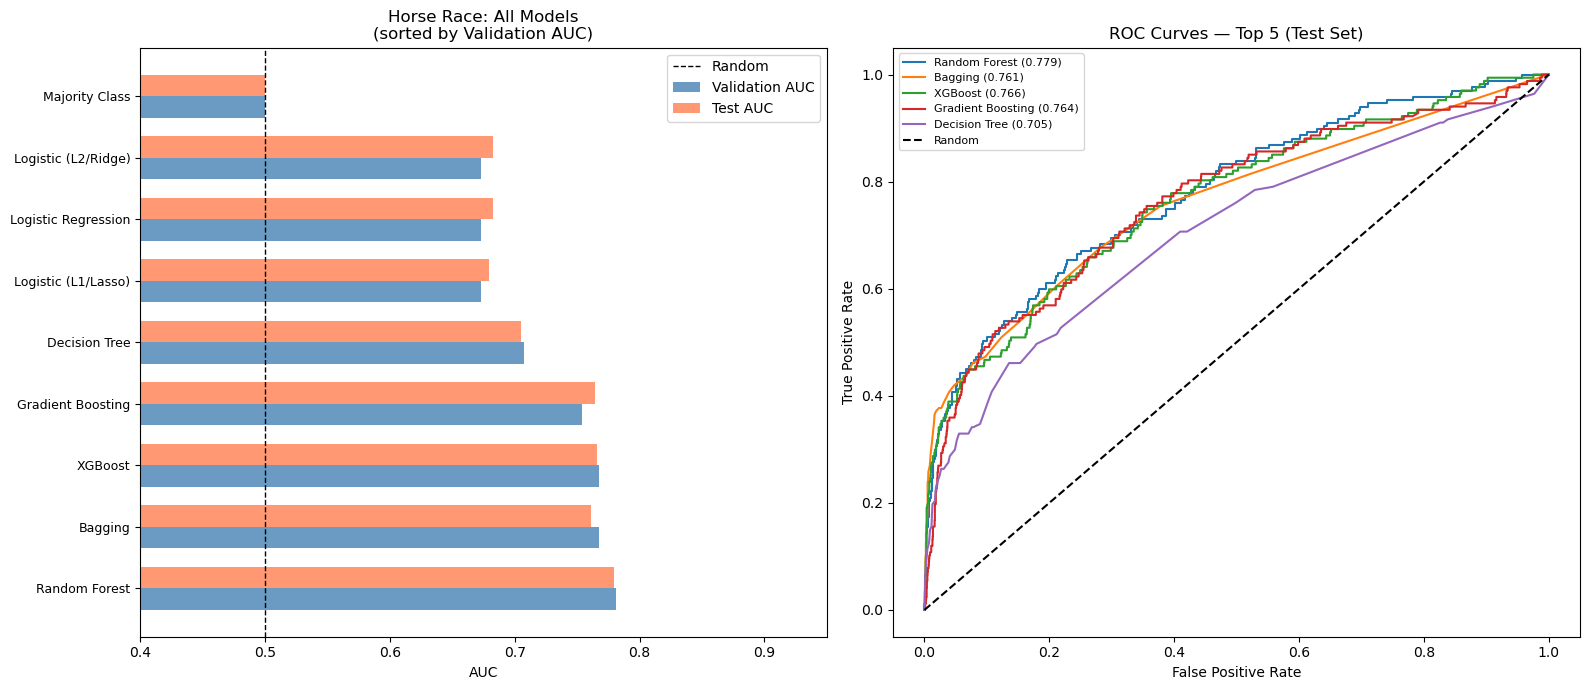

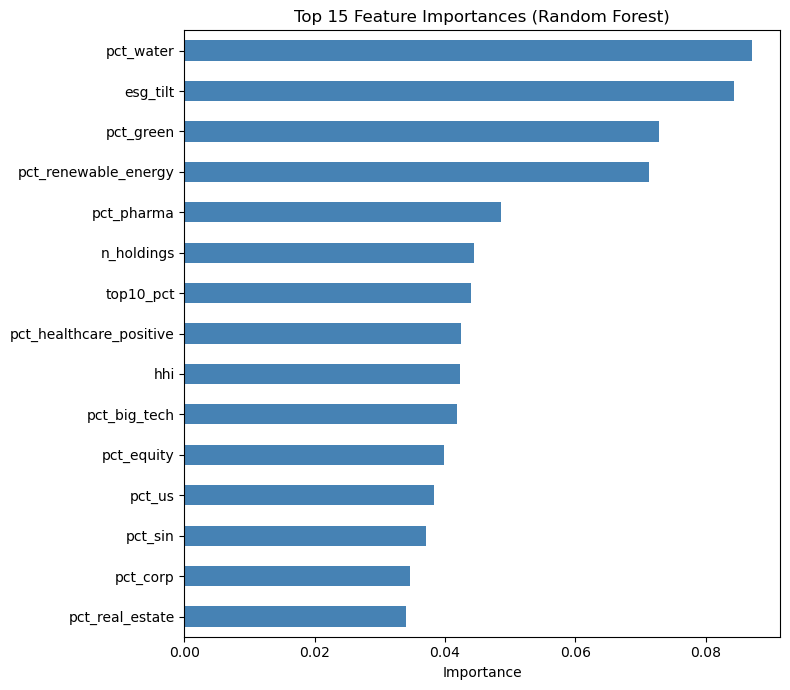

✓ Saved horse_race_results.csv


,model,val_auc,test_auc,best_params
5,Random Forest,0.781429,0.779176,"{'max_depth': None, 'min_samples_leaf': 10, 'n..."
6,Bagging,0.767916,0.760815,"{'max_samples': 0.8, 'n_estimators': 50}"
8,XGBoost,0.767882,0.766318,"{'learning_rate': 0.05, 'max_depth': 7, 'n_est..."
7,Gradient Boosting,0.753729,0.764002,"{'learning_rate': 0.2, 'max_depth': 5, 'n_esti..."
4,Decision Tree,0.707426,0.705143,"{'max_depth': 7, 'min_samples_leaf': 20}"
2,Logistic (L1/Lasso),0.673336,0.679257,{'C': 0.1}
1,Logistic Regression,0.673144,0.682394,{'C': 0.1}
3,Logistic (L2/Ridge),0.673144,0.682394,{'C': 0.1}
0,Majority Class,0.500000,0.500000,{}


In [62]:
print("=== ESG horse race ===")
result_esg = run_horse_race(features_df, "is_esg", FEATURE_COLS)

print(f"\nBest model: {result_esg['best_model_name']}")
print(f"Best test AUC: {max(result_esg['test_auc'].values()):.3f}")

plot_horse_race(result_esg, save_path=str(OUTPUT_DIR / "horse_race_all_models.png"))
plot_feature_importance(result_esg, FEATURE_COLS, save_path=str(OUTPUT_DIR / "feature_importance.png"))

# Save summary
summary = pd.DataFrame({
    "model"    : list(result_esg["val_auc"].keys()),
    "val_auc"  : list(result_esg["val_auc"].values()),
    "test_auc" : list(result_esg["test_auc"].values()),
    "best_params": [str(p) for p in result_esg["best_params"].values()],
}).sort_values("val_auc", ascending=False)
summary.to_csv(str(OUTPUT_DIR / "horse_race_results.csv"), index=False)
print("✓ Saved horse_race_results.csv")
summary


## Section 7 — Baseline AUCs (predictability horse race)

Re-run the same horse race for other fund-name categories (growth, value, etc.)
to see whether ESG's AUC is distinctively low.


In [63]:
baseline_label_configs = {
    "growth": {
        "include": [r"\bgrowth\b"],
        "exclude": [r"growth\s*&?\s*income", r"growth\s*and\s*income"],
    },
    "value": {
        "include": [r"\bvalue\b"],
        "exclude": [r"enterprise value", r"fair value"],
    },
    "small_cap": {
        "include": [r"\bsmall[\s\-]?cap\b", r"\bsmallcap\b",
                    r"\bsmall companies\b"],
        "exclude": [],
    },
    "large_cap": {
        "include": [r"\blarge[\s\-]?cap\b", r"\blargecap\b",
                    r"\blarge companies\b"],
        "exclude": [],
    },
    "international": {
        "include": [r"\binternational\b", r"\bglobal\b", r"\bworld\b",
                    r"\bex[\s\-]?us\b", r"\bex[\s\-]?u\.s\.\b",
                    r"\bemerging\s+markets?\b", r"\bdeveloped\s+markets?\b",
                    r"\bforeign\b", r"\boverseas\b"],
        "exclude": [],
    },
    "income": {
        "include": [r"\bincome\b", r"\bdividend\b", r"\byield\b"],
        "exclude": [r"growth\s*&?\s*income"],
    },
}

# Build all labels at once
for cat, cfg in baseline_label_configs.items():
    features_df[f"is_{cat}"] = apply_keyword_label(
        features_df["series_name"], cfg["include"], cfg["exclude"]
    )

# Print prevalence
print(f"  {'Category':<18} {'N pos':>8} {'Rate':>8}")
print(f"  {'ESG':<18} {features_df['is_esg'].sum():>8,} "
      f"{features_df['is_esg'].mean():>7.2%}")
for cat in baseline_label_configs:
    col = f"is_{cat}"
    print(f"  {cat:<18} {features_df[col].sum():>8,} "
          f"{features_df[col].mean():>7.2%}")


  Category              N pos     Rate
  ESG                     835   6.07%
  growth                1,111   8.08%
  value                   822   5.98%
  small_cap               671   4.88%
  large_cap               497   3.62%
  international         2,232  16.24%
  income                2,222  16.16%


In [64]:
# Run a full horse race for each category. ESG first as reference.
all_results = {"ESG": result_esg}
for cat in baseline_label_configs:
    print(f"\n>>> {cat.upper()} <<<")
    all_results[cat] = run_horse_race(features_df, f"is_{cat}",
                                       FEATURE_COLS, verbose=False)
    r = all_results[cat]
    if r.get("skipped"):
        print(f"  SKIPPED: {r['reason']}")
    else:
        print(f"  Best: {r['best_model_name']}  test AUC="
              f"{max(r['test_auc'].values()):.3f}")



>>> GROWTH <<<
  Best: XGBoost  test AUC=0.877

>>> VALUE <<<
  Best: XGBoost  test AUC=0.948

>>> SMALL_CAP <<<
  Best: XGBoost  test AUC=0.972

>>> LARGE_CAP <<<
  Best: XGBoost  test AUC=0.942

>>> INTERNATIONAL <<<
  Best: Random Forest  test AUC=0.965

>>> INCOME <<<
  Best: Bagging  test AUC=0.869


In [65]:
# Comparative summary table
print(f"{'Category':<20} {'N pos':>8} {'Pos rate':>10} "
      f"{'Best model':<22} {'Test AUC':>10}")
print("-" * 72)
rows = []
for cat, r in all_results.items():
    if r.get("skipped"):
        continue
    best_name = r["best_model_name"]
    best_auc  = r["test_auc"][best_name]
    print(f"{cat:<20} {r['n_pos_total']:>8,} {r['pos_rate']:>9.2%} "
          f"{best_name:<22} {best_auc:>10.3f}")
    rows.append({
        "category": cat,
        "n_positive": r["n_pos_total"],
        "pos_rate": r["pos_rate"],
        "best_model": best_name,
        "best_test_auc": best_auc,
        **{f"test_auc_{m}": r["test_auc"][m] for m in r["test_auc"]},
    })

pd.DataFrame(rows).to_csv(str(OUTPUT_DIR / "baseline_auc_comparison.csv"), index=False)
print("\n✓ Saved baseline_auc_comparison.csv")

# Quick interpretation
esg_auc    = max(all_results["ESG"]["test_auc"].values())
other_aucs = {c: max(all_results[c]["test_auc"].values())
              for c in all_results if c != "ESG" and not all_results[c].get("skipped")}
mean_other = np.mean(list(other_aucs.values()))
print(f"\nESG best test AUC      : {esg_auc:.3f}")
print(f"Mean of other categories: {mean_other:.3f}")
print(f"ESG vs. mean of others : {esg_auc - mean_other:+.3f}")


Category                N pos   Pos rate Best model               Test AUC
------------------------------------------------------------------------
ESG                       835     6.07% Random Forest               0.779
growth                  1,111     8.08% XGBoost                     0.877
value                     822     5.98% XGBoost                     0.946
small_cap                 671     4.88% XGBoost                     0.972
large_cap                 497     3.62% XGBoost                     0.942
international           2,232    16.24% Random Forest               0.960
income                  2,222    16.16% Bagging                     0.861

✓ Saved baseline_auc_comparison.csv

ESG best test AUC      : 0.779
Mean of other categories: 0.929
ESG vs. mean of others : -0.150


## Section 8 — Benchmark-adjusted tilt & green/sin/neutral analysis (richer dataset)

This section replaces the name-keyword tilt analysis of the earlier draft with a
**richer 2024 holdings dataset** that carries S&P Global ESG scores and CSA industry
classifications at the holding level.

**Redefined exposure categories**
- **Sin** — CSA-industry regex (fossil fuel, tobacco, aerospace & defense, gaming, beverage).
- **Green** — a *curated company list* seeded from hand-built names and extended by
  keyword-matched candidates from the holdings, minus an explicit false-positive list.
  The candidate list is written to `green_companies_audit.csv` for manual review; set
  `USE_AUDITED_LIST = True` after editing it to lock the reviewed version.
- **Neutral** — CSA-industry regex (big tech, financials, real estate, pharma, healthcare);
  reported as benchmark categories but excluded from the tilt.

**Two tilt definitions**
- `esg_tilt_inv` — involvement based: green share − sin share of the rated sleeve.
- `esg_tilt_score` — score based: high-tier share − low-tier share of the rated sleeve.

**Inputs (must already exist in `DATA_DIR`, i.e. `./data` by default)**
- `fund_tier_shares.csv` — per-fund within-industry score-tier shares (built externally).
- `holdings_tiered.csv` — holding-level file with `esg_score`, `csaindustryname`, tiers.
- `esg_net_scores.csv` — the `is_esg_final` labels, written by **Section 2** above.

In [ ]:
# ── 8.0  Section 8 config — paths for the richer ESG-scored dataset ──────
# Inputs come from DATA_DIR; generated files go to OUTPUT_DIR (both set in
# Section 0.2). The ESG labels (is_esg_final) are produced by Section 2; the two
# tiered files are built externally (see data/README.md) and must already sit in
# DATA_DIR before running this section.

FUND_SHARES_CSV   = str(DATA_DIR   / "fund_tier_shares.csv")          # input  (external; see data/README.md)
HOLDINGS_TIERED   = str(DATA_DIR   / "holdings_tiered.csv")           # input  (external; see data/README.md)
LABEL_CSV         = str(OUTPUT_DIR / "esg_net_scores.csv")           # input  (written by Section 2)

SHARES_LABELED    = str(OUTPUT_DIR / "fund_tier_shares_labeled.csv")  # written by 8.1
FUND_FEATURES_CSV = str(OUTPUT_DIR / "fund_involvement_labeled.csv")  # written by 8.2
AUDIT_CSV         = str(OUTPUT_DIR / "green_companies_audit.csv")     # written by 8.2

PLOT_DIR          = str(OUTPUT_DIR)
LABEL_COL         = "is_esg_final"
USE_AUDITED_LIST  = False     # set True after reviewing/editing green_companies_audit.csv

# Friendly preflight check so reproducers get a clear pointer instead of a cryptic error.
_missing = [p for p in (FUND_SHARES_CSV, HOLDINGS_TIERED, LABEL_CSV) if not os.path.exists(p)]
if _missing:
    print("⚠️  Section 8 inputs not found:")
    for p in _missing:
        print("     -", p)
    print("   The two tiered files require licensed S&P Global ESG data (via WRDS);")
    print("   see data/README.md for provenance, schemas, and how to rebuild them.")
    print("   esg_net_scores.csv is produced by running Section 2 above.")
else:
    print("✓ Section 8 inputs found. Outputs ->", OUTPUT_DIR)

### 8.1 — Join ESG labels onto within-industry tier shares + Cohen's *d*

Exact-name join with a normalized-name fallback, then Welch *t*, Mann–Whitney *U*, Cohen's *d*, Hedges' *g*, and a 95% CI for *d* on each score-tier share. Writes `fund_tier_shares_labeled.csv` (used by 8.2, 8.4, 8.6).

In [ ]:
"""
Join YOUR NLP ESG/non-ESG fund labels onto the within-industry tier shares,
then test group differences with Cohen's d.
"""

OUT_MERGED = SHARES_LABELED                          # fund_tier_shares_labeled.csv
OUT_TEST   = f"{OUTPUT_DIR}/esg_tier_group_test.csv"
# FUND_SHARES_CSV, LABEL_CSV, LABEL_COL all come from the Section 8 config cell
METRICS = ["pct_high_w", "pct_med_w", "pct_low_w", "pct_high_n", "pct_med_n", "pct_low_n"]

def norm(s):
    s = "" if pd.isna(s) else str(s)
    return re.sub(r"\s+", " ", s).strip().casefold()

shares = pd.read_csv(FUND_SHARES_CSV)
labels = pd.read_csv(LABEL_CSV)[["series_name", LABEL_COL]].copy()

# one label per name; if duplicates disagree, treat the name as ESG if ANY says ESG
labels[LABEL_COL] = labels[LABEL_COL].astype(str).str.strip().str.lower().isin(["true", "1", "yes"])
labels = labels.groupby("series_name", as_index=False)[LABEL_COL].max()

# ---- pass 1: exact name join ----
m = shares.merge(labels, on="series_name", how="left")

# ---- pass 2: normalized-name fallback for the unmatched ----
un = m[LABEL_COL].isna()
if un.any():
    lab2 = labels.copy(); lab2["k"] = lab2["series_name"].map(norm)
    lab2 = lab2.groupby("k", as_index=False)[LABEL_COL].max()
    fix  = m.loc[un, "series_name"].map(norm).map(lab2.set_index("k")[LABEL_COL])
    m.loc[un, LABEL_COL] = fix.values

matched = m[LABEL_COL].notna()
print(f"funds with tier shares : {len(m):,}")
print(f"matched exact          : {(~un).sum():,}")
print(f"matched after normalize: {matched.sum() - (~un).sum():,}")
print(f"still unmatched (dropped from test): {(~matched).sum():,}")
if (~matched).any():
    print("  sample unmatched names:", m.loc[~matched, "series_name"].head(5).tolist())

m.to_csv(OUT_MERGED, index=False)
dfm = m[matched].copy()
dfm[LABEL_COL] = dfm[LABEL_COL].astype(bool)

# ---- Cohen's d per tier share ----
def effect(a, b):
    a, b = a.dropna(), b.dropna()
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    d  = (a.mean() - b.mean()) / sp if sp > 0 else np.nan
    g  = d * (1 - 3/(4*(na+nb) - 9)) if np.isfinite(d) else np.nan
    se = np.sqrt((na+nb)/(na*nb) + d**2/(2*(na+nb))) if np.isfinite(d) else np.nan
    lo, hi = (d - 1.96*se, d + 1.96*se) if np.isfinite(se) else (np.nan, np.nan)
    _, p_t = stats.ttest_ind(a, b, equal_var=False)
    _, p_u = stats.mannwhitneyu(a, b, alternative="two-sided")
    return dict(n_esg=na, n_non=nb, mean_esg=a.mean(), mean_non=b.mean(),
                diff=a.mean()-b.mean(), cohens_d=d, hedges_g=g,
                d_ci_lo=lo, d_ci_hi=hi, welch_p=p_t, mwu_p=p_u)

A = dfm[dfm[LABEL_COL]]          # ESG-labeled funds
B = dfm[~dfm[LABEL_COL]]         # non-ESG funds
res = pd.DataFrame([{"metric": x, **effect(A[x], B[x])} for x in METRICS if x in dfm.columns])
res.to_csv(OUT_TEST, index=False)

show = res.copy()
for c in ["mean_esg", "mean_non", "diff"]:               show[c] = (show[c]*100).round(2)
for c in ["cohens_d", "hedges_g", "d_ci_lo", "d_ci_hi"]: show[c] = show[c].round(3)
for c in ["welch_p", "mwu_p"]:                           show[c] = show[c].map(lambda p: f"{p:.2e}")
pd.set_option("display.width", 200, "display.max_columns", 20)
print(f"\nESG funds n={len(A):,} | non-ESG funds n={len(B):,}  (means shown as %)\n")
print(show.to_string(index=False))
print(f"\nmerged shares+labels -> {OUT_MERGED}")
print(f"test results         -> {OUT_TEST}")

### 8.2 — Green / sin / neutral involvement + score-tier tilts (Cohen's *d* report)

Classifies the rated sleeve into the curated-green / industry-sin / industry-neutral buckets, builds both tilt columns, runs the pooled-SD Cohen's *d* report over every metric, and plots the two tilt distributions plus their joint scatter. Writes `fund_involvement_labeled.csv`, `cohens_d_report_v3.csv`, and the green audit list.

In [ ]:
"""
Cohen's d report v3 -- curated-list green, industry sin, score tiers, ESG-tilt.

SIN    : CSA industry regex (company-level professional classification).
GREEN  : CURATED COMPANY LIST -- seeded from your hand-built INDUSTRY_KEYWORDS
         (full company names only; all ticker fragments dropped), extended by
         keyword-matched candidates from the holdings, minus an explicit
         EXCLUDE list of known false positives. The final list is written to
         green_companies_audit.csv (name, category, source) -- REVIEW AND EDIT
         IT, then rerun with USE_AUDITED_LIST=True to lock your edited version.
TIERS  : within-industry high/med/low shares (from fund_tier_shares_labeled.csv).
TILTS  : esg_tilt_inv   = pct_green_total - pct_sin_total   (involvement-based)
         esg_tilt_score = pct_high_w     - pct_low_w        (score-based)
Stats  : Welch t, textbook pooled-SD Cohen's d, magnitude + stars.
Plots  : overlaid density histograms of both tilts (your format) + a scatter
         of the two tilts to show the two channels jointly.
"""

SHARES_CSV   = SHARES_LABELED          # written by cell 8.1
HOLDINGS_CSV = HOLDINGS_TIERED
OUT_CSV      = f"{OUTPUT_DIR}/cohens_d_report_v3.csv"
UNIT         = ["series_id"]
# AUDIT_CSV, PLOT_DIR, LABEL_COL, USE_AUDITED_LIST, FUND_FEATURES_CSV from config cell

# ---------------- SIN: CSA industries (unchanged) ----------------
SIN_IND_PATTERNS = {
    "pct_fossil_fuel":     r"oil & gas|coal",
    "pct_tobacco":         r"tobacco",
    "pct_weapons_defense": r"aerospace & defen",
    "pct_gambling":        r"casino|gaming",
    "pct_alcohol_bev":     r"beverage",
}

# ---------------- NEUTRAL: CSA industries (benchmark categories; in tests, NOT in tilt) ----------------
NEUTRAL_IND_PATTERNS = {
    "pct_big_tech":    r"software|semiconductor|computer|it services|interactive media|communications equip",
    "pct_financials":  r"\bbank|insurance|diversified financial|capital markets|consumer finance",
    "pct_real_estate": r"real estate",
    "pct_pharma":      r"pharmaceutical|biotech",
    "pct_healthcare":  r"health care",
}

# ---------------- GREEN: curated seed (full names only, tickers removed) ----------------
GREEN_SEED = {
 "renewable_energy": [
    "nextera energy","enphase","first solar","sunrun","vestas","orsted","ørsted",
    "brookfield renewable","plug power","bloom energy","solaredge","array technologies",
    "sunpower","sunnova","canadian solar","jinko","jinkosolar","daqo new energy",
    "xcel energy","avangrid","clearway energy","pattern energy","terraform",
    "innergex","boralex","northland power","atlantica sustainable","neoen","voltalia"],
 "clean_tech": [
    "tesla","rivian","lucid group","lucid motors","nio inc","xpeng","li auto",
    "albemarle","livent","chargepoint","blink charging","evgo","wallbox",
    "ballard power","fuelcell energy","itm power","ceres power","itron","ameresco",
    "clean harbors","freyr battery"],
 "water": [
    "xylem","veolia","american water works","essential utilities","middlesex water",
    "california water","york water","artesian resources","mueller water",
    "watts water","american states water","tetra tech"],
}
# keyword patterns used only as a CANDIDATE GENERATOR (pruned per earlier audit)
GREEN_KEYWORDS = {
 "renewable_energy": r"\bsolar\b|\bwind\b|renewab|photovolt|geotherm|hydroelectric|clean energy|green energy",
 "clean_tech":       r"clean tech|cleantech|fuel cell|electric vehicle|energy storage|\bbattery\b",
 "water":            r"water utilit|water works|water resources|water technolog",
}
# known false positives (substring, lowercase) -- never classified green
GREEN_EXCLUDE = ["norsk hydro","sl green","green brick","greene","primo water",
                 "select water","waters corp","green plains","gfl environmental",
                 "windstream","wind river","solaris oilfield","battery park"]

def name_norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()

# ---------------- load data ----------------
fund = pd.read_csv(SHARES_CSV)
fund = fund[fund[LABEL_COL].notna()].copy()
fund[LABEL_COL] = fund[LABEL_COL].astype(str).str.strip().str.lower().isin(["true","1","yes"])

h = pd.read_csv(HOLDINGS_CSV, low_memory=False)
h = h[h["esg_score"].notna() & (h["pct_nav"] > 0)].copy()          # rated sleeve
h["ind"]  = h["csaindustryname"].fillna("").str.lower()
h["name"] = h["security_name"].map(name_norm)

# ---------------- build / load the curated green list ----------------
if USE_AUDITED_LIST:
    gl = pd.read_csv(AUDIT_CSV)
    gl = gl[gl.get("keep", 1).astype(str).str.lower().isin(["1","true","yes"])]
    green_list = gl.groupby("category")["match_fragment"].apply(list).to_dict()
    print(f"using audited green list from {AUDIT_CSV} "
          f"({sum(len(v) for v in green_list.values())} fragments)")
else:
    green_list, audit_rows = {}, []
    excl_re = "|".join(re.escape(x) for x in GREEN_EXCLUDE)
    for cat, seeds in GREEN_SEED.items():
        frags = {s: "seed" for s in seeds}
        cand = h.loc[h["name"].str.contains(GREEN_KEYWORDS[cat], regex=True)
                     & ~h["name"].str.contains(excl_re, regex=True), "name"].unique()
        for nm in cand:                                   # company-name candidates from keywords
            if not any(s in nm for s in seeds):
                frags.setdefault(nm, "keyword")
        green_list[cat] = list(frags)
        audit_rows += [{"category": cat, "match_fragment": f, "source": src, "keep": 1}
                       for f, src in frags.items()]
    pd.DataFrame(audit_rows).to_csv(AUDIT_CSV, index=False)
    print(f"green candidate list written -> {AUDIT_CSV}")
    print("  REVIEW it (set keep=0 on bad rows, add rows), then set USE_AUDITED_LIST=True.")

# ---------------- classify holdings ----------------
print("\n=== AUDITS ===")
for nm, pat in SIN_IND_PATTERNS.items():
    h[nm] = h["ind"].str.contains(pat, regex=True)
    print(f"  [sin/industry] {nm:<22} -> "
          f"{', '.join(sorted(h.loc[h[nm], 'csaindustryname'].dropna().unique())[:6])}")
for nm, pat in NEUTRAL_IND_PATTERNS.items():
    h[nm] = h["ind"].str.contains(pat, regex=True)
    print(f"  [neutral/industry] {nm:<19} -> "
          f"{', '.join(sorted(h.loc[h[nm], 'csaindustryname'].dropna().unique())[:6])}")
GREEN_COLS = []
for cat, frags in green_list.items():
    col = f"pct_{cat}"; GREEN_COLS.append(col)
    pat = "|".join(r"\b" + re.escape(f) + r"\b" for f in sorted(frags, key=len, reverse=True))
    h[col] = h["name"].str.contains(pat, regex=True)
    ex = h.loc[h[col], "security_name"].dropna().drop_duplicates().head(4).tolist()
    print(f"  [green/list]   {col:<22} -> "
          f"{h.loc[h[col], 'security_name'].nunique():,} names, e.g. {ex}")
h["pct_sin_total"]   = h[list(SIN_IND_PATTERNS)].any(axis=1)
h["pct_green_total"] = h[GREEN_COLS].any(axis=1)

# ---------------- per-fund involvement shares (rated sleeve) ----------------
FEATS = (list(SIN_IND_PATTERNS) + ["pct_sin_total"] + GREEN_COLS + ["pct_green_total"]
         + list(NEUTRAL_IND_PATTERNS))
tot = h.groupby(UNIT)["pct_nav"].sum().rename("w_tot")
inv = pd.DataFrame(index=tot.index)
for nm in FEATS:
    inv[nm] = h[h[nm]].groupby(UNIT)["pct_nav"].sum()
inv = inv.fillna(0).div(tot, axis=0).reset_index()
fund = fund.merge(inv, on=UNIT, how="left")
for c in inv.columns:
    if c not in UNIT:
        fund[c] = fund[c].fillna(0)

# ---------------- the two tilt columns ----------------
fund["esg_tilt_inv"]   = fund["pct_green_total"] - fund["pct_sin_total"]
fund["esg_tilt_score"] = fund["pct_high_w"] - fund["pct_low_w"]

fund.to_csv(FUND_FEATURES_CSV, index=False)
print(f"fund-level features -> {FUND_FEATURES_CSV}")

# ---------------- report ----------------
FEATURE_TYPE = {**{k: "other" for k in NEUTRAL_IND_PATTERNS},
                **{k: "sin" for k in list(SIN_IND_PATTERNS) + ["pct_sin_total"]},
                **{k: "green" for k in GREEN_COLS + ["pct_green_total"]},
                "esg_tilt_inv": "green", "esg_tilt_score": "green",
                "pct_high_w": "green", "pct_med_w": "other", "pct_low_w": "sin",
                "pct_high_n": "green", "pct_med_n": "other", "pct_low_n": "sin"}
METRICS = (FEATS + ["esg_tilt_inv", "pct_high_w", "pct_med_w", "pct_low_w",
                    "pct_high_n", "pct_med_n", "pct_low_n", "esg_tilt_score"])

def stars(p): return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
def magnitude(d):
    a = abs(d)
    return "Negligible" if a < .2 else "Small" if a < .5 else "Medium" if a < .8 else "Large"

A = fund[fund[LABEL_COL]]; B = fund[~fund[LABEL_COL]]
rows = []
print(f"\n{'Feature':<24}{'ESG':>10}{'Bench':>10}{'Diff':>10}  Direction")
print("-" * 66)
for m in METRICS:
    a, b = A[m].dropna(), B[m].dropna()
    diff = a.mean() - b.mean()
    ftype = FEATURE_TYPE.get(m, "other")
    if   ftype == "sin":   direction = ("v Underweight sin"  if diff < 0 else "x OVERWEIGHT sin")
    elif ftype == "green": direction = ("v Overweight green" if diff > 0 else "x UNDERWEIGHT green")
    else:                  direction = "Neutral"
    print(f"{m:<24}{a.mean():>10.4f}{b.mean():>10.4f}{diff:>+10.4f}  {direction}")
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    d  = diff / sp if sp > 0 else np.nan
    _, p = stats.ttest_ind(a, b, equal_var=False)
    rows.append(dict(metric=m, type=ftype, mean_esg=a.mean(), mean_non=b.mean(),
                     diff=diff, cohens_d=d, welch_p=p, magnitude=magnitude(d), sig=stars(p)))
print(f"\n=== Cohen's d ===  (small=0.2, medium=0.5, large=0.8)")
for r in rows:
    print(f"  {r['metric']:<24} d={r['cohens_d']:+.3f}  {r['magnitude']:<11} {r['sig']}")
pd.DataFrame(rows).to_csv(OUT_CSV, index=False)
print(f"\nSaved -> {OUT_CSV}")

# ---------------- visualizations ----------------
def tilt_hist(col, xlabel, fname):
    ev, nv = A[col].dropna(), B[col].dropna()
    xmin, xmax = fund[col].quantile(0.01), fund[col].quantile(0.99)
    bins = np.linspace(xmin, xmax, 40)
    plt.figure(figsize=(8, 5))
    plt.hist(nv, bins=bins, density=True, alpha=0.5, label=f"Non-ESG (n={len(nv):,})")
    plt.hist(ev, bins=bins, density=True, alpha=0.5, label=f"ESG (n={len(ev):,})")
    plt.axvline(nv.median(), color="C0", linestyle="--", linewidth=1.2, label="Non-ESG median")
    plt.axvline(ev.median(), color="C1", linestyle="--", linewidth=1.2, label="ESG median")
    plt.xlabel(xlabel); plt.ylabel("Density"); plt.legend(); plt.tight_layout()
    path = f"{PLOT_DIR}/{fname}"
    plt.savefig(path, dpi=300); plt.show()
    print(f"plot -> {path}")

tilt_hist("esg_tilt_inv",
          "ESG Tilt, involvement-based (Green - Sin share of rated sleeve)",
          "distribution_esg_tilt_involvement.png")
tilt_hist("esg_tilt_score",
          "ESG Tilt, score-based (High-tier - Low-tier share of rated sleeve)",
          "distribution_esg_tilt_score.png")

# joint view: the two channels at once
plt.figure(figsize=(7, 6))
plt.scatter(B["esg_tilt_score"], B["esg_tilt_inv"], s=6, alpha=0.25, label="Non-ESG")
plt.scatter(A["esg_tilt_score"], A["esg_tilt_inv"], s=10, alpha=0.55, label="ESG")
plt.axhline(0, lw=0.6, color="grey"); plt.axvline(0, lw=0.6, color="grey")
plt.xlabel("Score-based tilt (high - low tier)")
plt.ylabel("Involvement-based tilt (green - sin)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/tilt_scatter.png", dpi=300); plt.show()
print(f"plot -> {PLOT_DIR}/tilt_scatter.png")

### 8.3 — Involvement-based bin distributions (green / sin / neutral)

Binned share-of-funds tables and grouped bar charts for the involvement categories, ESG vs. non-ESG, as % of the rated equity sleeve.

In [ ]:
"""
Binned distribution tables + histograms for the INVOLVEMENT-based classification
(green / sin / neutral), same format as the tier-bin script: for ESG and non-ESG
funds separately, bin | num_funds | share_of_funds_pct, plus grouped bar charts.
Reads the fund-level features saved by cohens_d_report_v3.py
(fund_involvement_labeled.csv) -- run that first. Shares are % of the rated
equity sleeve.
"""

MERGED_CSV = FUND_FEATURES_CSV          # fund_involvement_labeled.csv (from cell 8.2)
OUT_CSV    = f"{OUTPUT_DIR}/involvement_bin_distributions.csv"
# PLOT_DIR, LABEL_COL from config cell

BINS   = [-0.001, 0, 1, 2.5, 5, 10, 20, 50, 80, 100, np.inf]
LABELS = ["0%", "(0, 1%]", "(1%, 2.5%]", "(2.5%, 5%]", "(5%, 10%]",
          "(10%, 20%]", "(20%, 50%]", "(50%, 80%]", "80%, 100%", ">100%"]

df = pd.read_csv(MERGED_CSV)
df = df[df[LABEL_COL].notna()].copy()
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower().isin(["true","1","yes"])

# involvement metrics, converted to PERCENT units
RAW = {
    "green_total_pct": "pct_green_total",
    "sin_total_pct":   "pct_sin_total",
    "big_tech_pct":    "pct_big_tech",
    "financials_pct":  "pct_financials",
    "real_estate_pct": "pct_real_estate",
    "pharma_pct":      "pct_pharma",
    "healthcare_pct":  "pct_healthcare",
}
METRICS = []
for new, old in RAW.items():
    if old in df.columns:
        df[new] = df[old] * 100
        METRICS.append(new)
    else:
        print(f"(skipping {old} -- not in file)")

def bin_table(series, group_name, metric):
    b = pd.cut(series, bins=BINS, labels=LABELS, include_lowest=True)
    out = (b.value_counts(sort=False).rename_axis("bin").reset_index(name="num_funds"))
    out.insert(0, "metric", metric)
    out.insert(1, "group", group_name)
    out["share_of_funds_pct"] = out["num_funds"] / len(series) * 100
    return out

all_tabs = []
for m in METRICS:
    for is_esg, gname in [(True, "ESG"), (False, "non-ESG")]:
        s = df.loc[df[LABEL_COL] == is_esg, m].dropna()
        tab = bin_table(s, gname, m)
        all_tabs.append(tab)
        print(f"\n=== {m} | {gname} funds (n={len(s):,}) ===")
        show = tab[["bin", "num_funds", "share_of_funds_pct"]].copy()
        show["share_of_funds_pct"] = show["share_of_funds_pct"].round(2)
        print(show.to_string(index=False))

res = pd.concat(all_tabs, ignore_index=True)
res.to_csv(OUT_CSV, index=False)
print(f"\nSaved -> {OUT_CSV}")

for m in METRICS:
    sub = res[res["metric"] == m]
    e  = sub[sub["group"] == "ESG"].set_index("bin")["share_of_funds_pct"].reindex(LABELS)
    ne = sub[sub["group"] == "non-ESG"].set_index("bin")["share_of_funds_pct"].reindex(LABELS)
    x = np.arange(len(LABELS)); wdt = 0.38
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - wdt/2, ne.values, wdt, label=f"non-ESG (n={int((~df[LABEL_COL]).sum()):,})")
    ax.bar(x + wdt/2, e.values,  wdt, label=f"ESG (n={int(df[LABEL_COL].sum()):,})")
    ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=30, ha="right")
    ax.set_ylabel("share of funds (%)")
    ax.set_title(f"Distribution across bins: {m}")
    ax.legend()
    fig.tight_layout()
    path = f"{PLOT_DIR}/bins_{m}.png"
    fig.savefig(path, dpi=150); plt.show()
    print(f"plot -> {path}")

### 8.4 — Score-tier bin distributions (high / med / low)

Same binned-distribution format for the score-tier shares, both within the rated sleeve and as a share of whole NAV.

In [ ]:
"""
Binned distribution tables + histograms, in your green-asset-bins format,
for ESG and non-ESG funds separately.
"""

MERGED_CSV = SHARES_LABELED             # fund_tier_shares_labeled.csv (from cell 8.1)
OUT_CSV    = f"{OUTPUT_DIR}/tier_bin_distributions.csv"
# PLOT_DIR, LABEL_COL from config cell

BINS   = [-0.001, 0, 1, 2.5, 5, 10, 20, 50, 80, 100, np.inf]
LABELS = ["0%", "(0, 1%]", "(1%, 2.5%]", "(2.5%, 5%]", "(5%, 10%]",
          "(10%, 20%]", "(20%, 50%]", "(50%, 80%]","(80%, 100%]", ">100%"]

df = pd.read_csv(MERGED_CSV)
df = df[df[LABEL_COL].notna()].copy()
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower().isin(["true","1","yes"])

# metrics in PERCENT units
for t in ("high", "med", "low"):
    df[f"{t}_rated_pct"] = df[f"pct_{t}_w"] * 100                  # share of rated sleeve
    df[f"{t}_nav_pct"]   = df[f"pct_{t}_w"] * df["rated_weight"]   # share of whole NAV
METRICS = ["high_rated_pct", "med_rated_pct", "low_rated_pct",
           "high_nav_pct",   "med_nav_pct",   "low_nav_pct"]

def bin_table(series, group_name, metric):
    b = pd.cut(series, bins=BINS, labels=LABELS, include_lowest=True)
    out = (b.value_counts(sort=False).rename_axis("bin").reset_index(name="num_funds"))
    out.insert(0, "metric", metric)
    out.insert(1, "group", group_name)
    out["share_of_funds_pct"] = out["num_funds"] / len(series) * 100
    return out

all_tabs = []
for m in METRICS:
    for is_esg, gname in [(True, "ESG"), (False, "non-ESG")]:
        s = df.loc[df[LABEL_COL] == is_esg, m].dropna()
        tab = bin_table(s, gname, m)
        all_tabs.append(tab)
        print(f"\n=== {m} | {gname} funds (n={len(s):,}) ===")
        show = tab[["bin", "num_funds", "share_of_funds_pct"]].copy()
        show["share_of_funds_pct"] = show["share_of_funds_pct"].round(2)
        print(show.to_string(index=False))

res = pd.concat(all_tabs, ignore_index=True)
res.to_csv(OUT_CSV, index=False)
print(f"\nSaved -> {OUT_CSV}")

# ---- grouped bar 'histograms': share of funds per bin, ESG vs non-ESG ----
for m in METRICS:
    sub = res[res["metric"] == m]
    e  = sub[sub["group"] == "ESG"].set_index("bin")["share_of_funds_pct"].reindex(LABELS)
    ne = sub[sub["group"] == "non-ESG"].set_index("bin")["share_of_funds_pct"].reindex(LABELS)
    x = np.arange(len(LABELS)); wdt = 0.38
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - wdt/2, ne.values, wdt, label=f"non-ESG (n={int((~df[LABEL_COL]).sum()):,})")
    ax.bar(x + wdt/2, e.values,  wdt, label=f"ESG (n={int(df[LABEL_COL].sum()):,})")
    ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=30, ha="right")
    ax.set_ylabel("share of funds (%)")
    ax.set_title(f"Distribution across bins: {m}")
    ax.legend()
    fig.tight_layout()
    path = f"{PLOT_DIR}/bins_{m}.png"
    fig.savefig(path, dpi=150); plt.show()
    print(f"plot -> {path}")

### 8.5 — Who passes the green test?

Pulls the funds in the extreme green bins (non-ESG > 80%, ESG > 50%) and lists their top rated-sleeve holdings, marking green positions, to check whether the high-green non-ESG funds are concentrated single-name vehicles.

In [ ]:
# %% ════════════════════════════════════════════════════════════════════════
# Who passes the green test? Pulls the funds in the extreme green bins of
# Table 4 Panel A and shows their top rated-sleeve holdings.
#
#   A. non-ESG funds with pct_green_total > 80%   (the "five funds" footnote)
#   B. ESG funds with pct_green_total > 50%       (the four funds in (50,80])
#
# Reads the fund-level file your v3 cell already saves
# (fund_involvement_labeled.csv: value-weighted shares of the rated sleeve,
# fractions 0-1, labels attached), then looks up each flagged fund's holdings
# in holdings_tiered.csv. Green positions are marked using the same audited
# fragment list the v3 cell wrote (green_companies_audit.csv).
# ════════════════════════════════════════════════════════════════════════════

HOLDINGS_CSV = HOLDINGS_TIERED
OUT_CSV      = f"{OUTPUT_DIR}/green_bin_extreme_funds.csv"
TOP_N        = 6              # top positions to display per fund
CHUNK        = 1_000_000
# FUND_FEATURES_CSV, AUDIT_CSV, LABEL_COL from config cell

def name_norm(s):
    s = "" if pd.isna(s) else str(s)
    return re.sub(r"\s+", " ", s).strip().lower()

# ── 1. flag the funds from the saved fund-level file ─────────────────────────
fund = pd.read_csv(FUND_FEATURES_CSV)
fund[LABEL_COL] = (fund[LABEL_COL].astype(str).str.strip().str.lower()
                   .isin(["true", "1", "yes"]))
fund["series_id"] = fund["series_id"].astype(str).str.strip()

nonesg_80 = fund[(~fund[LABEL_COL]) & (fund["pct_green_total"] > 0.80)].copy()
esg_50    = fund[( fund[LABEL_COL]) & (fund["pct_green_total"] > 0.50)].copy()
flagged   = pd.concat([nonesg_80.assign(group="non-ESG >80%"),
                       esg_50.assign(group="ESG >50%")], ignore_index=True)
flagged   = flagged.sort_values(["group", "pct_green_total"], ascending=[True, False])

print(f"non-ESG funds with green share > 80%: {len(nonesg_80)}   "
      f"(table says 0.07% of 6,969 = ~5)")
print(f"ESG funds with green share > 50%   : {len(esg_50)}   (table says 4)\n")

cols = [c for c in ["series_id", "series_name", "pct_green_total",
                    "pct_renewable_energy", "pct_clean_tech", "pct_water",
                    "n_rated"] if c in flagged.columns]
show = flagged[["group"] + cols].copy()
for c in show.columns:
    if c.startswith("pct_"):
        show[c] = (show[c] * 100).round(1)
print(show.to_string(index=False), "\n")

# ── 2. green-fragment matcher from the audit file (same fragments v3 used) ───
try:
    gl = pd.read_csv(AUDIT_CSV)
    if "keep" in gl.columns:
        gl = gl[gl["keep"].astype(str).str.lower().isin(["1", "true", "yes"])]
    frags = sorted(set(gl["match_fragment"].dropna().map(name_norm)))
    green_pat = re.compile("|".join(re.escape(f) for f in frags if f))
    print(f"green matcher rebuilt from audit file: {len(frags)} fragments")
except Exception as e:
    green_pat = None
    print(f"(could not rebuild green matcher from {AUDIT_CSV}: {e})")

# ── 3. pull each flagged fund's rated-sleeve holdings ────────────────────────
keep_ids = set(flagged["series_id"])
use = ["series_id", "series_name", "registrant_name",
       "security_name", "pct_nav", "esg_score"]
parts = []
for ch in pd.read_csv(HOLDINGS_CSV, usecols=lambda c: c in use,
                      chunksize=CHUNK, low_memory=False):
    ch["series_id"] = ch["series_id"].astype(str).str.strip()
    sub = ch[ch["series_id"].isin(keep_ids)]
    if len(sub):
        parts.append(sub)
h = pd.concat(parts, ignore_index=True)
h["pct_nav"]   = pd.to_numeric(h["pct_nav"], errors="coerce")
h["esg_score"] = pd.to_numeric(h["esg_score"], errors="coerce")
h = h[h["esg_score"].notna() & (h["pct_nav"] > 0)]          # rated sleeve, as in v3

rows_out = []
for _, f in flagged.iterrows():
    sid = f["series_id"]
    g = h[h["series_id"] == sid]
    reg = g["registrant_name"].iloc[0] if "registrant_name" in g and len(g) else ""
    top = (g.groupby("security_name", as_index=False)["pct_nav"].sum()
             .sort_values("pct_nav", ascending=False))
    top["sleeve_share"] = top["pct_nav"] / top["pct_nav"].sum()
    print("─" * 78)
    print(f"[{f['group']}] {f['series_name']}  ({sid})"
          + (f"  |  registrant: {reg}" if reg else ""))
    print(f"   green share of rated sleeve: {f['pct_green_total']*100:.1f}%   "
          f"rated positions: {len(g):,}")
    for _, r in top.head(TOP_N).iterrows():
        mark = ""
        if green_pat is not None:
            mark = "  <- GREEN" if green_pat.search(name_norm(r["security_name"])) else ""
        print(f"      {r['sleeve_share']:6.1%}  {r['security_name'][:58]}{mark}")
        rows_out.append(dict(group=f["group"], series_id=sid,
                             series_name=f["series_name"], registrant=reg,
                             green_share=f["pct_green_total"],
                             holding=r["security_name"],
                             sleeve_share=r["sleeve_share"]))

pd.DataFrame(rows_out).to_csv(OUT_CSV, index=False)
print("─" * 78)
print(f"\nfull detail -> {OUT_CSV}")
print("""
WHAT TO DO WITH THE OUTPUT:
  If the non-ESG >80% funds are single-name vehicles (e.g., Tesla ETFs), the
  footnote in Section IV.D can state it flatly -- replace "evidently ...
  concentrated single-name vehicles" with the verified description and delete
  the TODO. If any is a genuine diversified green fund, paste the output back
  and the footnote (and the 'passed exclusively by funds that do not carry ESG
  names' sentence) will be softened accordingly.""")

### 8.6 — Tier-share distributions (summary stats + histograms / box plots)

Per-group summary tables (mean, sd, quantiles) and overlaid histograms + box plots for each tier share, within the rated sleeve and as a share of whole NAV.

In [ ]:
"""
Distributions of tier shares for ESG vs non-ESG funds.
Reads fund_tier_shares_labeled.csv and produces, per group:
  - summary tables (mean, sd, quantiles) for each tier share
  - overlaid histograms + box plots, saved as PNGs
Two share definitions:
  (a) within the RATED equity sleeve (pct_*_w; the three sum to 1)  [what you tested]
  (b) share of the WHOLE fund's NAV: pct_*_w * rated_weight/100
"""

MERGED_CSV = SHARES_LABELED             # fund_tier_shares_labeled.csv (from cell 8.1)
OUT_STATS  = f"{OUTPUT_DIR}/tier_distribution_stats.csv"
# PLOT_DIR, LABEL_COL from config cell

df = pd.read_csv(MERGED_CSV)
df = df[df[LABEL_COL].notna()].copy()
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower().isin(["true", "1", "yes"])

# whole-asset (share of total NAV) versions: pct_nav is % of net assets,
# so rated_weight is in 0-100 units
for t in ("high", "med", "low"):
    df[f"pct_{t}_nav"] = df[f"pct_{t}_w"] * df["rated_weight"] / 100.0

METRICS = {
    "pct_high_w":  "High tier - share of rated sleeve",
    "pct_med_w":   "Medium tier - share of rated sleeve",
    "pct_low_w":   "Low tier - share of rated sleeve",
    "pct_high_nav":"High tier - share of whole NAV",
    "pct_med_nav": "Medium tier - share of whole NAV",
    "pct_low_nav": "Low tier - share of whole NAV",
}
QS = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

rows = []
for m in METRICS:
    for is_esg, gname in [(True, "ESG"), (False, "non-ESG")]:
        s = df.loc[df[LABEL_COL] == is_esg, m].dropna() * 100
        rows.append({"metric": m, "group": gname, "n": len(s),
                     "mean": s.mean(), "sd": s.std(ddof=1),
                     **{f"q{int(q*100):02d}": s.quantile(q) for q in QS}})
stats_df = pd.DataFrame(rows).round(2)
stats_df.to_csv(OUT_STATS, index=False)
pd.set_option("display.width", 220, "display.max_columns", 25)
print(stats_df.to_string(index=False))

for fname, keys, ttl in [
    ("tier_dist_rated.png", ["pct_high_w", "pct_med_w", "pct_low_w"],
     "Tier shares within rated sleeve"),
    ("tier_dist_nav.png",   ["pct_high_nav", "pct_med_nav", "pct_low_nav"],
     "Tier shares of whole NAV"),
]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for j, m in enumerate(keys):
        a = df.loc[df[LABEL_COL],  m].dropna() * 100
        b = df.loc[~df[LABEL_COL], m].dropna() * 100
        ax = axes[0, j]
        bins = np.linspace(0, max(a.max(), b.max(), 1), 40)
        ax.hist(b, bins=bins, density=True, alpha=0.55, label=f"non-ESG (n={len(b):,})")
        ax.hist(a, bins=bins, density=True, alpha=0.55, label=f"ESG (n={len(a):,})")
        ax.axvline(b.mean(), ls="--", lw=1.2, color="C0")
        ax.axvline(a.mean(), ls="--", lw=1.2, color="C1")
        ax.set_title(METRICS[m], fontsize=10); ax.set_xlabel("%"); ax.legend(fontsize=8)
        ax = axes[1, j]
        ax.boxplot([b, a], labels=["non-ESG", "ESG"], showmeans=True, vert=True)
        ax.set_ylabel("%")
    fig.suptitle(ttl)
    fig.tight_layout()
    path = f"{PLOT_DIR}/{fname}"
    fig.savefig(path, dpi=150); plt.show()
    print(f"plot -> {path}")

print(f"stats -> {OUT_STATS}")